In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load your cleaned file
df = pd.read_csv(
    r'C:\Users\priya\OneDrive\Desktop\healthcare-project\data\Cleaned\healthcare_clean.csv'
)
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])

print('Loaded successfully!')
print('Rows:', len(df))
print('Columns:', df.columns.tolist())

Loaded successfully!
Rows: 54860
Columns: ['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results', 'length_of_stay', 'admission_year', 'admission_month', 'month_name', 'age_group']


In [5]:
import os
charts_path = r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts'
os.makedirs(charts_path, exist_ok=True)
print('Charts folder ready!')

Charts folder ready!


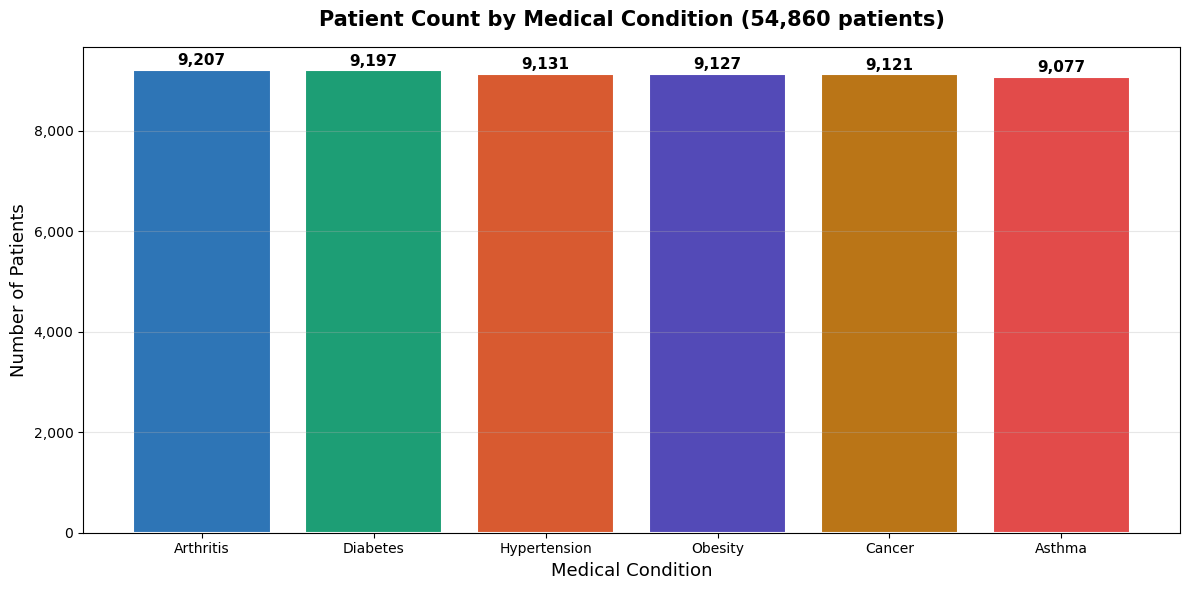

Chart 1 saved!


In [6]:
disease_counts = df['medical_condition'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2E75B6','#1D9E75','#D85A30','#534AB7','#BA7517','#E24B4A']
bars = ax.bar(disease_counts.index, disease_counts.values,
              color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, disease_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{val:,}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Patient Count by Medical Condition (54,860 patients)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Medical Condition', fontsize=13)
ax.set_ylabel('Number of Patients', fontsize=13)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chart1_disease_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

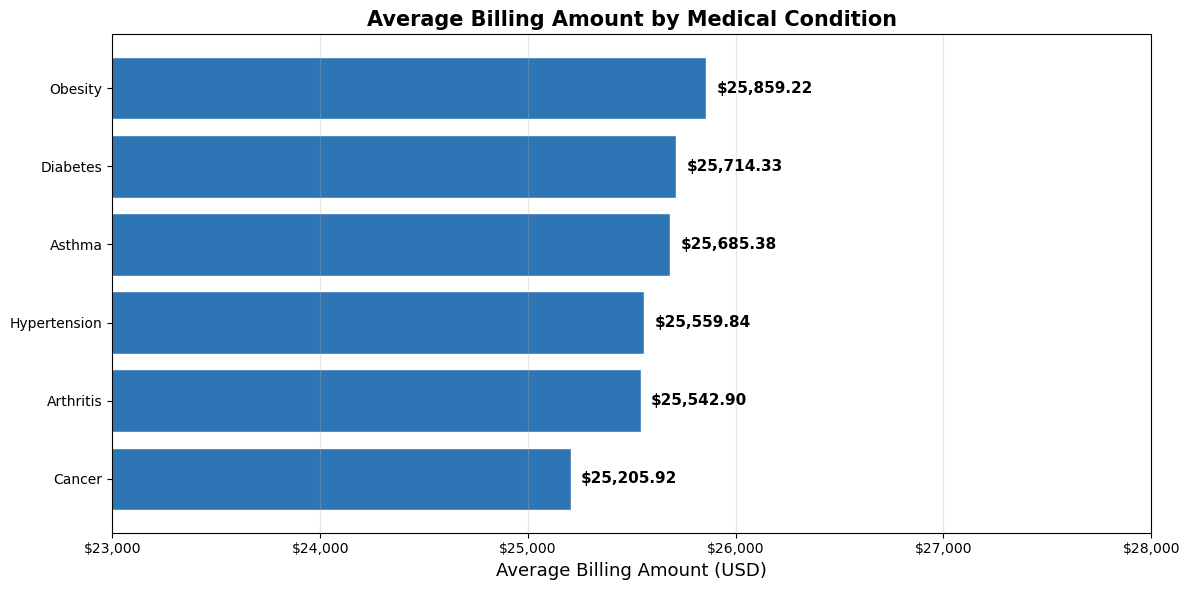

Chart 2 saved!


In [8]:
billing_avg = (df.groupby('medical_condition')['billing_amount']
                .mean()
                .sort_values(ascending=True)
                .round(2))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(billing_avg.index, billing_avg.values,
               color='#2E75B6', edgecolor='white', linewidth=1)

for bar, val in zip(bars, billing_avg.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'${val:,.2f}',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('Average Billing Amount by Medical Condition',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Average Billing Amount (USD)', fontsize=13)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.set_xlim(23000, 28000)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chart2_billing_disease.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')

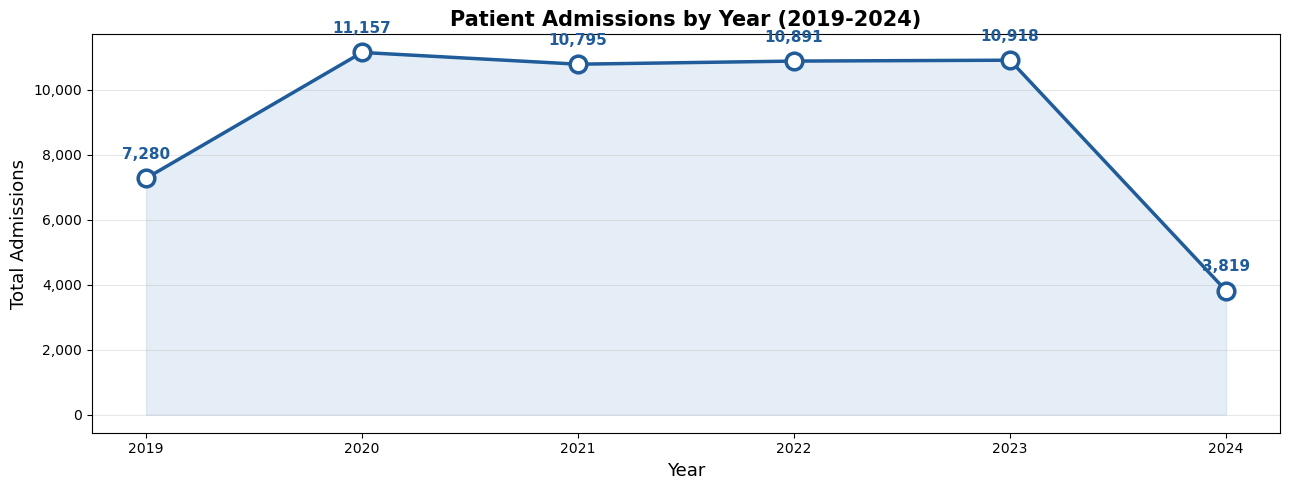

Chart 3 saved!


In [10]:
yearly = df.groupby('admission_year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly['admission_year'], yearly['count'],
        marker='o', linewidth=2.5,
        color='#1F5C99',
        markersize=12,
        markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(yearly['admission_year'], yearly['count'],
                alpha=0.12, color='#2E75B6')

for _, row in yearly.iterrows():
    ax.annotate(f"{int(row['count']):,}",
                xy=(row['admission_year'], row['count']),
                xytext=(0, 14), textcoords='offset points',
                ha='center', fontsize=11,
                fontweight='bold', color='#1F5C99')

ax.set_title('Patient Admissions by Year (2019-2024)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Total Admissions', fontsize=13)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(yearly['admission_year'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chart3_yearly_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

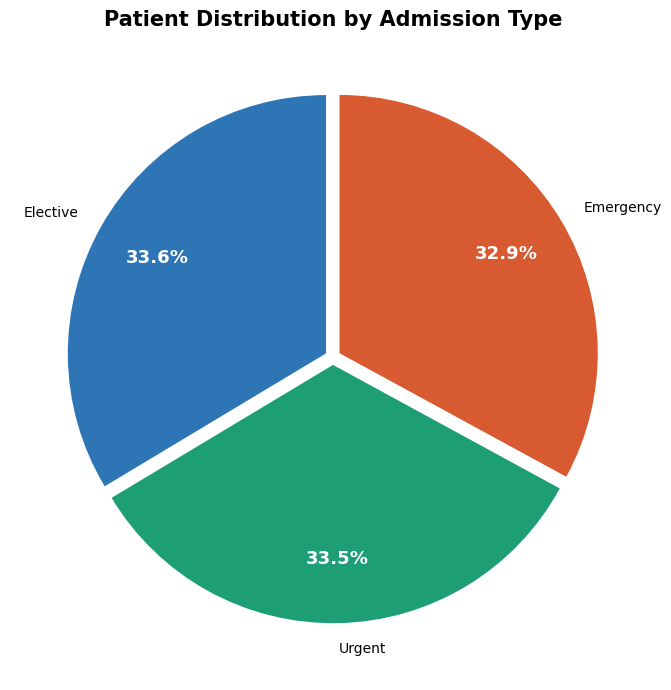

Chart 4 saved!


In [12]:
adm_counts = df['admission_type'].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
colors_pie = ['#2E75B6', '#1D9E75', '#D85A30']
wedges, texts, autotexts = ax.pie(
    adm_counts.values,
    labels=adm_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    pctdistance=0.75,
    explode=[0.03, 0.03, 0.03]
)
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('white')
ax.set_title('Patient Distribution by Admission Type',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chartX_name.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved!')


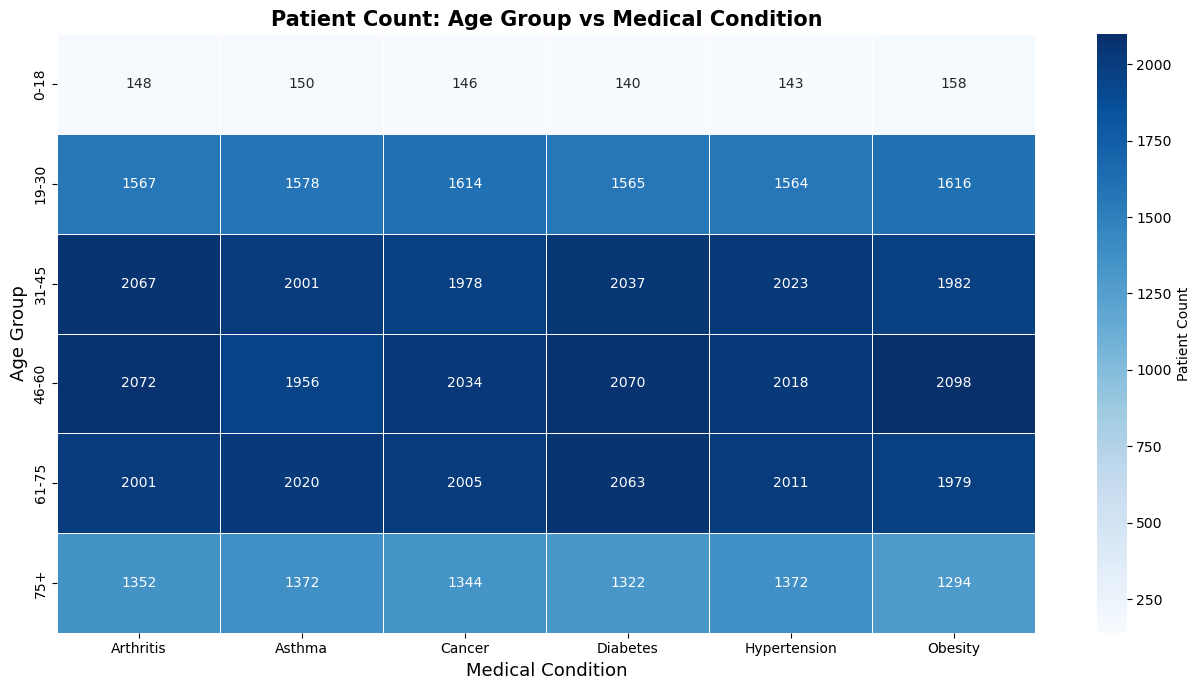

Chart 5 saved!


In [14]:
age_disease = pd.crosstab(
    df['age_group'],
    df['medical_condition']
)
age_order = ['0-18', '19-30', '31-45', '46-60', '61-75', '75+']
age_disease = age_disease.reindex(
    [a for a in age_order if a in age_disease.index]
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    age_disease,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Patient Count'},
    annot_kws={'size': 10}
)
ax.set_title('Patient Count: Age Group vs Medical Condition',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Medical Condition', fontsize=13)
ax.set_ylabel('Age Group', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chartX_name.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved!')

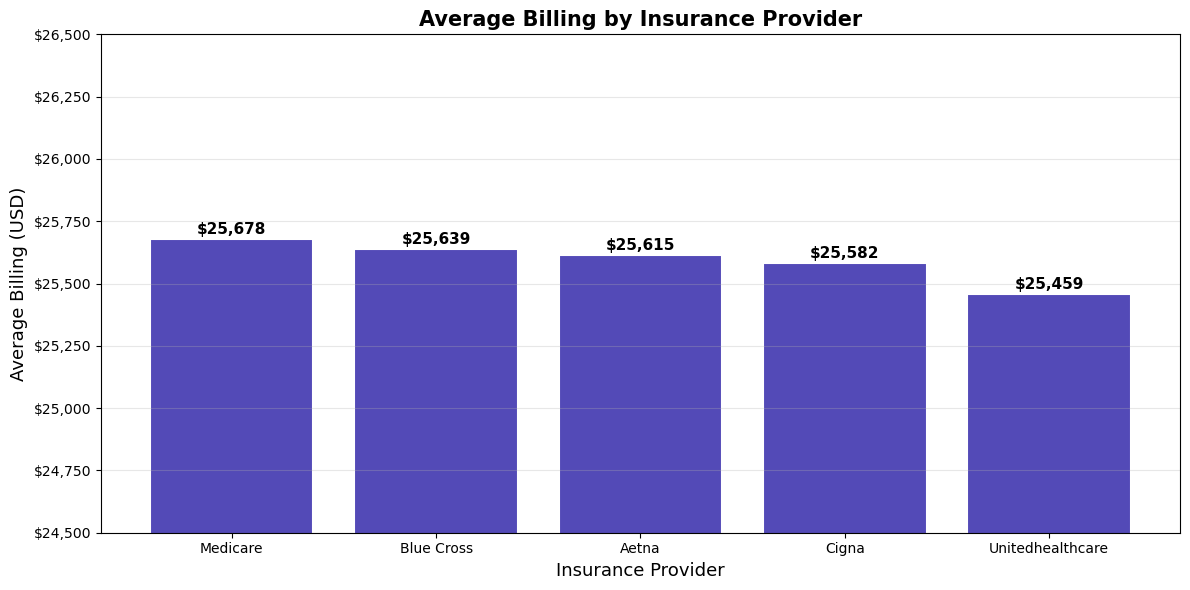

Chart 6 saved!


In [15]:
ins_billing = (
    df.groupby('insurance_provider')['billing_amount']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(ins_billing.index, ins_billing.values,
              color='#534AB7', edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, ins_billing.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'${val:,.0f}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Average Billing by Insurance Provider',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Insurance Provider', fontsize=13)
ax.set_ylabel('Average Billing (USD)', fontsize=13)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.set_ylim(24500, 26500)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chartX_name.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved!')

=== CLUSTER AVERAGES ===
          age  billing_amount  length_of_stay
cluster                                      
0        52.6         25378.0            24.6
1        69.4         25815.7             9.7
2        32.9         25641.0            10.3

=== GROUP SUMMARY ===
                    age  billing_amount  length_of_stay
risk_group                                             
High Cost Group    69.4         25815.7             9.7
Low Cost Group     52.6         25378.0            24.6
Medium Cost Group  32.9         25641.0            10.3

Group sizes:
Low Cost Group       20787
Medium Cost Group    17343
High Cost Group      16730
Name: risk_group, dtype: int64


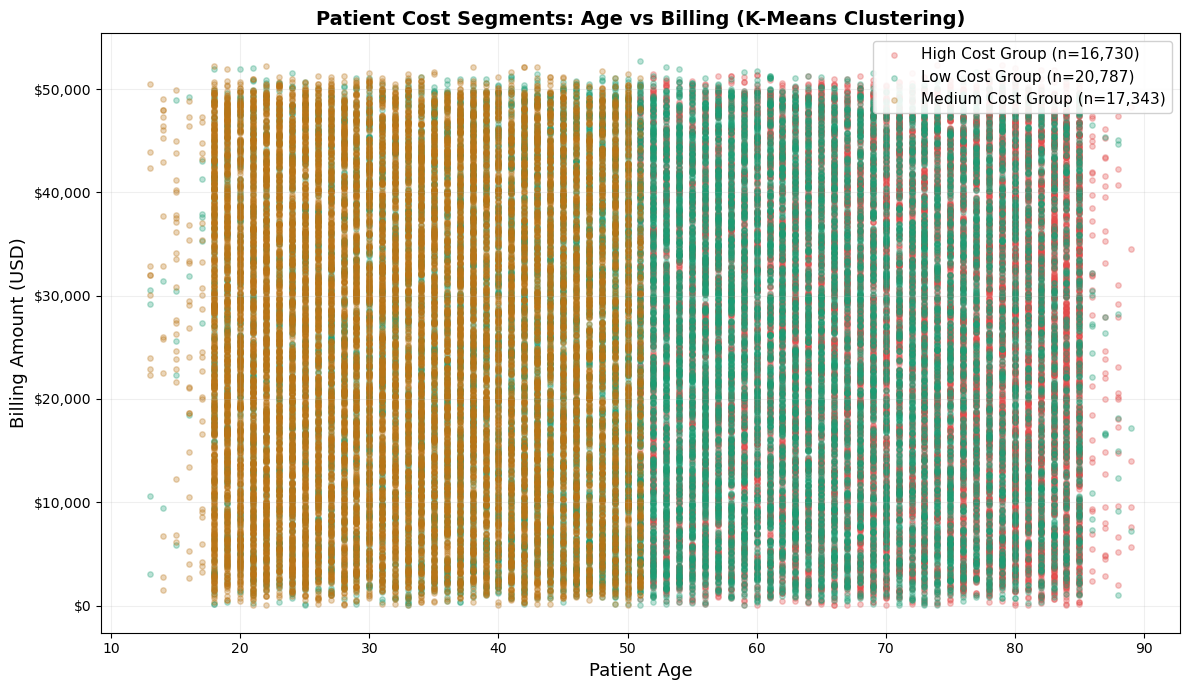

Chart 7 saved!


In [17]:
# Prepare the 3 features for clustering
features = ['age', 'billing_amount', 'length_of_stay']
X = df[features].dropna().copy()

# Normalize so all features have equal weight
# (billing is in thousands, age in tens — normalize makes them equal)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means — group into 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X['cluster'] = kmeans.fit_predict(X_scaled)

# See what each cluster looks like
print('=== CLUSTER AVERAGES ===')
print(X.groupby('cluster')[features].mean().round(1))

# Name clusters based on billing amount
means = X.groupby('cluster')['billing_amount'].mean()
sorted_c = means.sort_values().index.tolist()
name_map = {
    sorted_c[0]: 'Low Cost Group',
    sorted_c[1]: 'Medium Cost Group',
    sorted_c[2]: 'High Cost Group'
}
X['risk_group'] = X['cluster'].map(name_map)

# Print group summary
print()
print('=== GROUP SUMMARY ===')
summary = X.groupby('risk_group')[features].mean().round(1)
print(summary)
print()
print('Group sizes:')
print(X['risk_group'].value_counts())

# Plot
colors_c = {
    'Low Cost Group':    '#1D9E75',
    'Medium Cost Group': '#BA7517',
    'High Cost Group':   '#E24B4A'
}
fig, ax = plt.subplots(figsize=(12, 7))
for label, grp in X.groupby('risk_group'):
    ax.scatter(
        grp['age'], grp['billing_amount'],
        label=f'{label} (n={len(grp):,})',
        alpha=0.3, s=15,
        color=colors_c[label]
    )

ax.set_xlabel('Patient Age', fontsize=13)
ax.set_ylabel('Billing Amount (USD)', fontsize=13)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax.set_title(
    'Patient Cost Segments: Age vs Billing (K-Means Clustering)',
    fontsize=14, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(r'C:\Users\priya\OneDrive\Desktop\healthcare-project\charts\chartX_name.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved!')